In [1]:
import pandas as pd
df=pd.read_csv("golf_weather_dataset.csv")
df.head()

,day,outlook,temperature,humidity,wind,play_golf
0,1,rainy,25,59,weak,yes
1,2,sunny,27,75,weak,yes
2,3,overcast,35,64,weak,no
3,4,rainy,19,34,weak,yes
4,5,rainy,29,57,weak,no


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
le = LabelEncoder()
df['outlook']= le.fit_transform(df['outlook'])
df['temperature']= le.fit_transform(df['temperature'])
df['humidity']= le.fit_transform(df['humidity'])
df["wind"]= le.fit_transform(df['wind'])
df["play_golf"]= le.fit_transform(df['play_golf'])

In [3]:
X = df.iloc[:,1:-1]
y = df[['play_golf']]
X

,outlook,temperature,humidity,wind
0,1,10,29,1
1,2,12,45,1
2,0,20,34,1
3,1,4,4,1
4,1,14,27,1
...,...,...,...,...
1495,1,12,28,1
1496,2,19,62,1
1497,2,1,34,0
1498,1,12,43,1


In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
y

,play_golf
0,1
1,1
2,0
3,1
4,0
...,...
1495,0
1496,1
1497,0
1498,1


In [6]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.77

[Text(0.5, 0.875, 'x[3] <= 0.5\ngini = 0.5\nsamples = 1200\nvalue = [596, 604]'),
 Text(0.25, 0.625, 'x[0] <= 0.5\ngini = 0.388\nsamples = 483\nvalue = [356.0, 127.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[2] <= 28.5\ngini = 0.492\nsamples = 151\nvalue = [85, 66]'),
 Text(0.0625, 0.125, 'gini = 0.489\nsamples = 66\nvalue = [28, 38]'),
 Text(0.1875, 0.125, 'gini = 0.442\nsamples = 85\nvalue = [57.0, 28.0]'),
 Text(0.375, 0.375, 'x[0] <= 1.5\ngini = 0.3\nsamples = 332\nvalue = [271, 61]'),
 Text(0.3125, 0.125, 'gini = 0.104\nsamples = 145\nvalue = [137, 8]'),
 Text(0.4375, 0.125, 'gini = 0.406\nsamples = 187\nvalue = [134.0, 53.0]'),
 Text(0.75, 0.625, 'x[2] <= 45.5\ngini = 0.445\nsamples = 717\nvalue = [240, 477]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[0] <= 1.5\ngini = 0.391\nsamples = 533\nvalue = [142, 391]'),
 Text(0.5625, 0.125, 'gini = 0.461\nsamples = 325\nvalue = [117, 208]'),
 Text(0.6875, 0.125, 'gini = 0.211\nsamples = 208\nvalue = [25, 183]'

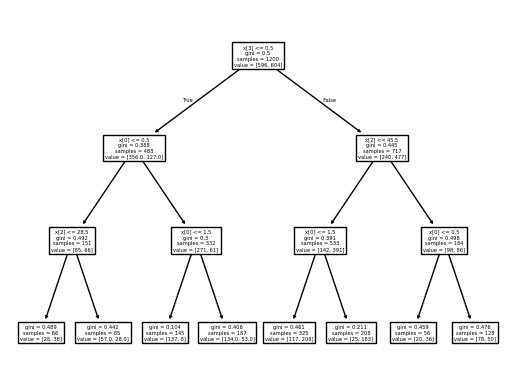

In [8]:
from sklearn.tree import plot_tree
plot_tree(model)